In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load and prepare the data
df = pd.read_csv("ml-latest-small/ratings.csv")
df = df.drop(columns=["timestamp"])

# Train-test split (80/20)
#train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

train_matrix = train_df.pivot(index="userId", columns="movieId", values="rating").fillna(0)
test_matrix = test_df.pivot(index="userId", columns="movieId", values="rating").fillna(0)

In [14]:
def cosine_sim(matrix):
    return cosine_similarity(matrix.fillna(0))

def adjusted_cosine_sim(matrix):
    matrix_centered = matrix.sub(matrix.mean(axis=1), axis=0)
    return cosine_similarity(matrix_centered.fillna(0))

def pearson_sim(matrix):
    matrix = matrix.fillna(0).values
    mean_user_rating = np.true_divide(matrix.sum(1), (matrix != 0).sum(1))
    matrix_centered = matrix - mean_user_rating[:, np.newaxis]
    matrix_centered[np.isnan(matrix_centered)] = 0
    sim = cosine_similarity(matrix_centered)
    return sim

def jaccard_sim(matrix):
    binarized = matrix.fillna(0).astype(bool).astype(int).values
    return 1 - pairwise_distances(binarized, metric="jaccard")

In [15]:
def predict_rating(user_id, item_id, sim_matrix, rating_matrix, k=10, mode='user'):
    if mode == 'user':
        if item_id not in rating_matrix.columns:
            return np.nan
        sims = sim_matrix[user_id - 1]
        ratings = rating_matrix[item_id]
    else:
        if user_id not in rating_matrix.index:
            return np.nan
        sims = sim_matrix[rating_matrix.columns.get_loc(item_id)]
        ratings = rating_matrix.loc[user_id]

    mask = ratings > 0
    sims = sims[mask]
    ratings = ratings[mask]

    if len(ratings) == 0:
        return np.nan

    top_k = np.argsort(sims)[-k:]
    sim_scores = sims[top_k]
    rating_scores = ratings.iloc[top_k]

    if sim_scores.sum() == 0:
        return np.nan

    return np.dot(sim_scores, rating_scores) / np.sum(sim_scores)

In [16]:
def evaluate(test_df, train_matrix, sim_matrix, k, mode='user'):
    true_ratings = []
    pred_ratings = []
    true_binary = []
    pred_binary = []

    for _, row in test_df.iterrows():
        user_id = int(row['userId'])
        item_id = int(row['movieId'])

        if mode == 'user' and user_id not in train_matrix.index:
            continue
        if mode == 'item' and item_id not in train_matrix.columns:
            continue

        true_rating = row['rating']
        pred = predict_rating(user_id, item_id, sim_matrix, train_matrix, k, mode=mode)

        if not np.isnan(pred):
            true_ratings.append(true_rating)
            pred_ratings.append(pred)
            true_binary.append(1 if true_rating >= 4 else 0)
            pred_binary.append(1 if pred >= 4 else 0)

    if len(true_ratings) == 0:
        return np.nan, np.nan, np.nan, np.nan

    mae = mean_absolute_error(true_ratings, pred_ratings)
    rmse = np.sqrt(mean_squared_error(true_ratings, pred_ratings))
    precision = precision_score(true_binary, pred_binary, zero_division=0)
    recall = recall_score(true_binary, pred_binary, zero_division=0)
    return mae, rmse, precision, recall

In [17]:
similarity_functions = {
    "cosine": cosine_sim,
    "adjusted_cosine": adjusted_cosine_sim,
    "pearson": pearson_sim,
    "jaccard": jaccard_sim,
}

k_values = [5, 10, 20, 30, 50, 75, 100]
results = []

for mode in ['user', 'item']:
    for name, sim_func in similarity_functions.items():
        print(f"\n{mode.upper()}-BASED: Calculating {name} similarity...")
        sim_matrix = sim_func(train_matrix if mode == 'user' else train_matrix.T)

        for k in k_values:
            print(f"Evaluating {mode}-based CF with {name} similarity and k = {k}")
            mae, rmse, precision, recall = evaluate(test_df, train_matrix, sim_matrix, k, mode=mode)
            results.append((mode, name, k, mae, rmse, precision, recall))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["mode", "similarity", "k", "mae", "rmse", "precision", "recall"])
print(results_df)


USER-BASED: Calculating cosine similarity...
Evaluating user-based CF with cosine similarity and k = 5
Evaluating user-based CF with cosine similarity and k = 10
Evaluating user-based CF with cosine similarity and k = 20
Evaluating user-based CF with cosine similarity and k = 30
Evaluating user-based CF with cosine similarity and k = 50
Evaluating user-based CF with cosine similarity and k = 75
Evaluating user-based CF with cosine similarity and k = 100

USER-BASED: Calculating adjusted_cosine similarity...
Evaluating user-based CF with adjusted_cosine similarity and k = 5
Evaluating user-based CF with adjusted_cosine similarity and k = 10
Evaluating user-based CF with adjusted_cosine similarity and k = 20
Evaluating user-based CF with adjusted_cosine similarity and k = 30
Evaluating user-based CF with adjusted_cosine similarity and k = 50
Evaluating user-based CF with adjusted_cosine similarity and k = 75
Evaluating user-based CF with adjusted_cosine similarity and k = 100

USER-BASE

c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Evaluating user-based CF with jaccard similarity and k = 5
Evaluating user-based CF with jaccard similarity and k = 10
Evaluating user-based CF with jaccard similarity and k = 20
Evaluating user-based CF with jaccard similarity and k = 30
Evaluating user-based CF with jaccard similarity and k = 50
Evaluating user-based CF with jaccard similarity and k = 75
Evaluating user-based CF with jaccard similarity and k = 100

ITEM-BASED: Calculating cosine similarity...
Evaluating item-based CF with cosine similarity and k = 5
Evaluating item-based CF with cosine similarity and k = 10
Evaluating item-based CF with cosine similarity and k = 20
Evaluating item-based CF with cosine similarity and k = 30
Evaluating item-based CF with cosine similarity and k = 50
Evaluating item-based CF with cosine similarity and k = 75
Evaluating item-based CF with cosine similarity and k = 100

ITEM-BASED: Calculating adjusted_cosine similarity...
Evaluating item-based CF with adjusted_cosine similarity and k = 5

c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Evaluating item-based CF with jaccard similarity and k = 5
Evaluating item-based CF with jaccard similarity and k = 10
Evaluating item-based CF with jaccard similarity and k = 20
Evaluating item-based CF with jaccard similarity and k = 30
Evaluating item-based CF with jaccard similarity and k = 50
Evaluating item-based CF with jaccard similarity and k = 75
Evaluating item-based CF with jaccard similarity and k = 100
    mode       similarity    k       mae      rmse  precision    recall
0   user           cosine    5  0.775427  1.000297   0.679007  0.369640
1   user           cosine   10  0.756884  0.978144   0.691489  0.334477
2   user           cosine   20  0.750072  0.970320   0.701671  0.315180
3   user           cosine   30  0.748933  0.968997   0.704795  0.302530
4   user           cosine   50  0.749949  0.969903   0.700415  0.289237
5   user           cosine   75  0.750871  0.970566   0.702515  0.281518
6   user           cosine  100  0.751413  0.971111   0.704362  0.280446
7   

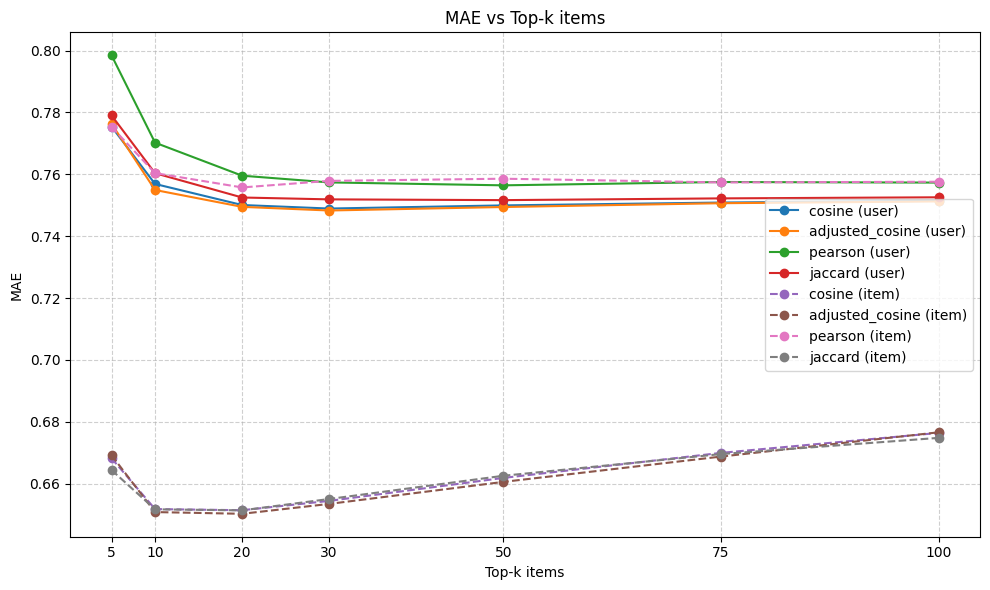

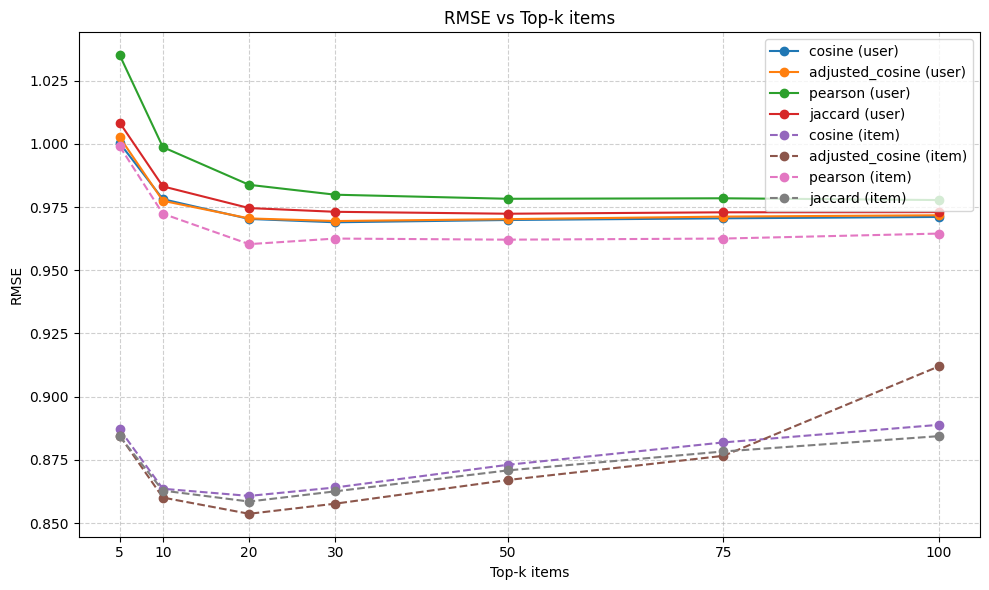

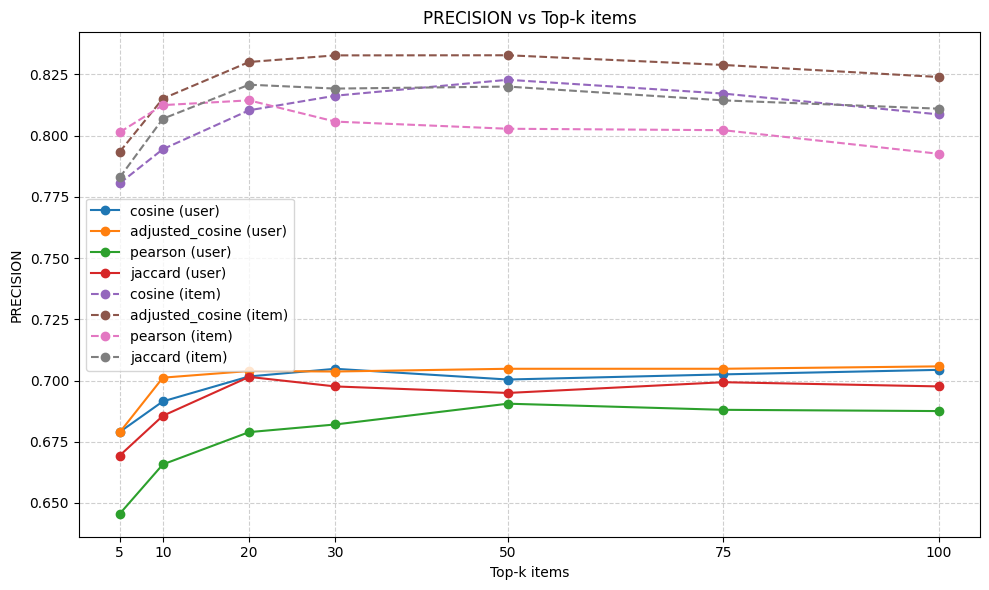

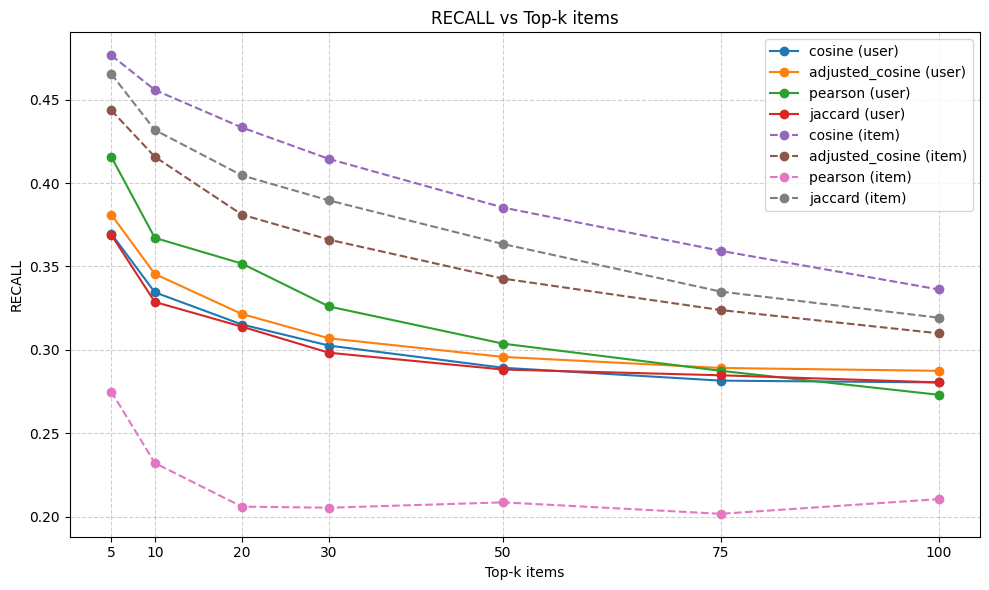

In [22]:
# Plotting: one graph per k value
metrics = ["mae", "rmse", "precision", "recall"]
k_values = sorted(results_df["k"].unique())
styles = {'user': 'solid', 'item': 'dashed'}

for metric in metrics:
    plt.figure(figsize=(10, 6))

    for mode in ['user', 'item']:
        for sim in results_df["similarity"].unique():
            subset = results_df[(results_df["mode"] == mode) & (results_df["similarity"] == sim)]
            y = subset.sort_values("k")[metric]
            label = f"{sim} ({mode})"
            plt.plot(k_values, y, marker='o', linestyle=styles[mode], label=label)

    plt.title(f"{metric.upper()} vs Top-k items")
    plt.xlabel("Top-k items")
    plt.ylabel(metric.upper())
    plt.xticks(k_values)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()